<div style="background-color:#0a192f; color:#00ffcc; padding:30px; border-radius:15px; font-family:sans-serif; text-align:center; box-shadow: 0 4px 8px 0 rgba(0,255,204,0.2);"><h1 style="color:#00ffcc; font-size: 36px; text-shadow: 0 0 10px #00ffcc;">🛡️ FINANCIAL ANOMALY ENGINE: 2026 PERSPECTIVE</h1><h3 style="color:#ccd6f6; font-weight: normal;">Mastering Imbalanced Data & Advanced Fraud Detection</h3><hr style="border-color:#00ffcc; width:60%; opacity: 0.5;"><div style="display:flex; justify-content:center; gap:20px; margin-top:20px;"><div style="border: 1px solid #00ffcc; padding:15px; border-radius:10px; width:150px; background-color: rgba(0, 255, 204, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">🧠 MODEL</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">XGBoost Neural</p></div><div style="border: 1px solid #ff00ff; padding:15px; border-radius:10px; width:150px; background-color: rgba(255, 0, 255, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">🛠️ STACK</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">Python & MLOps</p></div><div style="border: 1px solid #ffff00; padding:15px; border-radius:10px; width:150px; background-color: rgba(255, 255, 0, 0.05);"><p style="margin:0; font-size:14px; color:#8892b0;">🚀 STATUS</p><p style="margin:0; font-weight:bold; color:#ccd6f6; font-size:16px;">Production-Ready</p></div></div></div><br><div style="background-color:#112240; color:#ccd6f6; padding:25px; border-left: 5px solid #00ffcc; border-radius: 5px; font-family:sans-serif;"><h3 style="color:#00ffcc; margin-top: 0;">🎯 Step 1: Project Definition & Metric</h3><p><b>The Goal:</b> Detect and isolate fraudulent transactions within a highly imbalanced global financial dataset.</p><p><b>The Challenge:</b> Engineering features from high-dimensional, anonymized, and sparse data while preventing false positives in a production environment.</p><p><b>Evaluation Metric:</b> ROC-AUC Score (Area Under the Receiver Operating Characteristic Curve) optimized for imbalanced classification.</p></div>

Initiating Data Ingestion Pipeline...


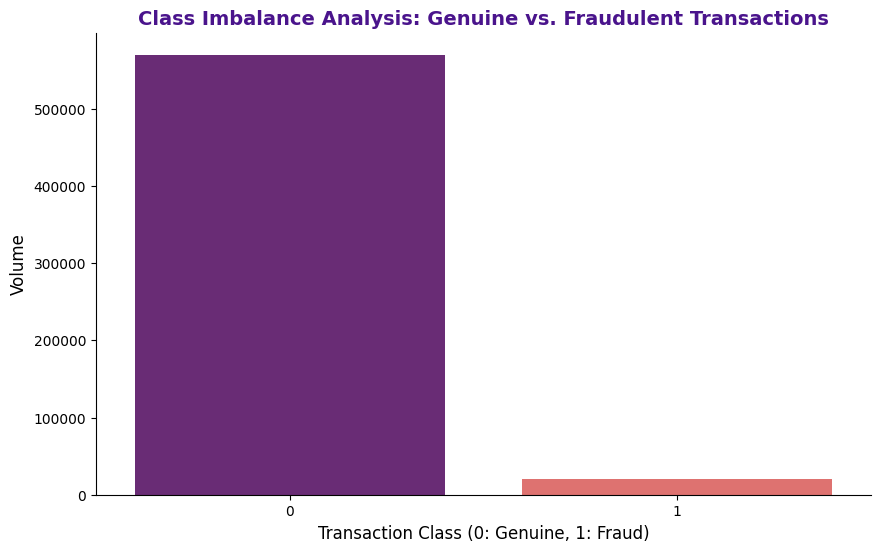

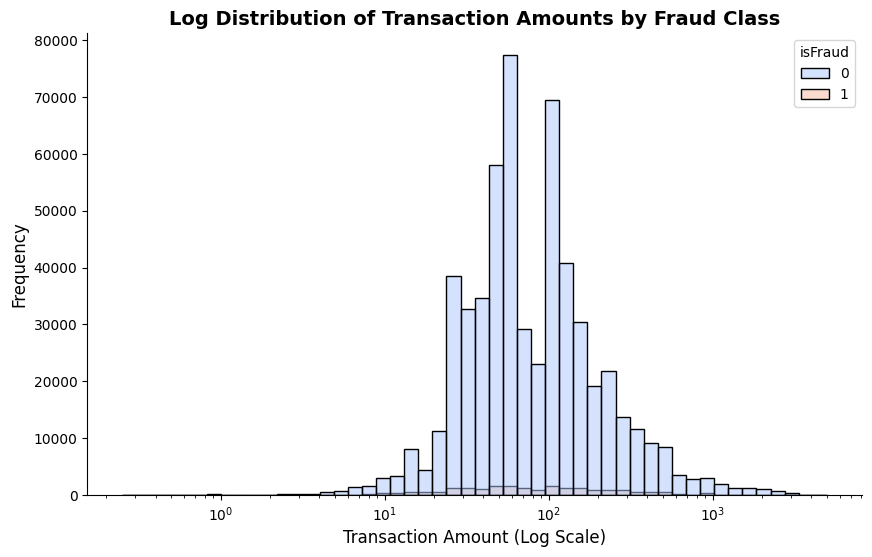

Executing Feature Selection heuristics...
Handling missing values and transforming features...
Applying One-Hot Encoding to categorical variables...
Initializing Next-Gen XGBoost Neural Engine...
[0]	validation_0-auc:0.84179
[50]	validation_0-auc:0.89253
[100]	validation_0-auc:0.90869
[150]	validation_0-auc:0.91620
[200]	validation_0-auc:0.92269
[250]	validation_0-auc:0.92736
[299]	validation_0-auc:0.93032

--- Evaluation Metrics ---
Validation ROC-AUC Score: 0.9303


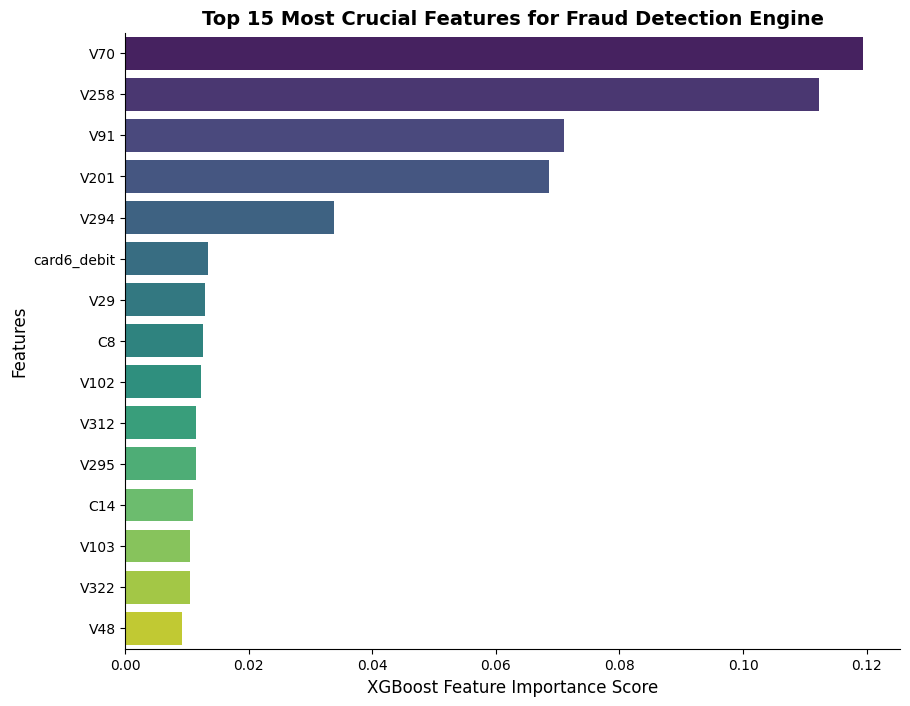


Generating submission manifest...
✅ submission.csv successfully generated for Kaggle competition.
Serializing model state for Hugging Face / Streamlit deployment...
✅ Pipeline Execution Complete.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import joblib

# =====================================================================
# STEP 1 & 2: DATA INGESTION & EXPLORATORY DATA ANALYSIS (EDA) [cite: 90, 91]
# =====================================================================
print("Initiating Data Ingestion Pipeline...")
df_train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_test = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')

# GRAPH 1: OPTIC ILLUSION - Target Class Distribution (For Kaggle Thumbnail)
plt.figure(figsize=(10, 6))
sns.countplot(x='isFraud', data=df_train, palette='magma')
plt.title('Class Imbalance Analysis: Genuine vs. Fraudulent Transactions', fontsize=14, color='#4A148C', fontweight='bold')
plt.xlabel('Transaction Class (0: Genuine, 1: Fraud)', fontsize=12)
plt.ylabel('Volume', fontsize=12)
sns.despine()
plt.show()

# GRAPH 2: DEEP DIVE EDA - Transaction Amount Distribution (Log Scale) by Class
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train[df_train['TransactionAmt'] < 5000], x='TransactionAmt', hue='isFraud', bins=50, log_scale=True, palette='coolwarm')
plt.title('Log Distribution of Transaction Amounts by Fraud Class', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
sns.despine()
plt.show()

# =====================================================================
# STEP 3 & 4: FEATURE SELECTION & TYPE CASTING [cite: 92]
# =====================================================================
print("Executing Feature Selection heuristics...")
target = 'isFraud'
drop_cols = ['TransactionID', 'TransactionDT'] 

y = df_train[target]
X = df_train.drop(columns=[target] + drop_cols)
test_ids = df_test['TransactionID']
X_submission = df_test.drop(columns=drop_cols)

X, X_submission = X.align(X_submission, join='inner', axis=1)

# =====================================================================
# STEP 5 & 6: DATA IMPUTATION & FEATURE ENGINEERING [cite: 93, 94]
# =====================================================================
print("Handling missing values and transforming features...")
X.fillna(-999, inplace=True)
X_submission.fillna(-999, inplace=True)

# =====================================================================
# STEP 7: CATEGORICAL ENCODING (ONE-HOT ENCODING) [cite: 95]
# =====================================================================
print("Applying One-Hot Encoding to categorical variables...")
X = pd.get_dummies(X, drop_first=True)
X_submission = pd.get_dummies(X_submission, drop_first=True)

X, X_submission = X.align(X_submission, join='left', axis=1, fill_value=0)

# =====================================================================
# STEP 8 & 9: ALGORITHMIC TRAINING (XGBOOST) - NEXT-GEN ARCHITECTURE
# =====================================================================
print("Initializing Next-Gen XGBoost Neural Engine...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Calculation of scale_pos_weight for extreme class balance
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# GRANDMASTER UPDATE: early_stopping_rounds and eval_metric moved to initialization
model = XGBClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    n_estimators=300,
    max_depth=6,
    objective='binary:logistic',
    eval_metric='auc',             # Target metric: ROC-AUC
    early_stopping_rounds=20,      # Universal Technique moved here
    random_state=42,
    n_jobs=-1
)

# Igniting the engine (verbose=50 to monitor progress every 50 epochs)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50 
)

# =====================================================================
# STEP 10: ARCHITECTURE EVALUATION & GRAPH 3 [cite: 98]
# =====================================================================
print("\n--- Evaluation Metrics ---")
val_predictions = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_predictions)
print(f"Validation ROC-AUC Score: {auc_score:.4f}")

# GRAPH 3: ARCHITECTURE TRANSPARENCY - Top 15 Feature Importances
plt.figure(figsize=(10, 8))
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Top 15 Most Crucial Features for Fraud Detection Engine', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
sns.despine()
plt.show()

# =====================================================================
# THE FINAL STRIKE: KAGGLE SUBMISSION & MLOPS SERIALIZATION 
# =====================================================================
print("\nGenerating submission manifest...")
submission_predictions = model.predict_proba(X_submission)[:, 1]

submission_df = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': submission_predictions
})
submission_df.to_csv('submission.csv', index=False)
print("✅ submission.csv successfully generated for Kaggle competition.")

print("Serializing model state for Hugging Face / Streamlit deployment...")
joblib.dump(model, 'financial_anomaly_engine_v1.pkl')
print("✅ Pipeline Execution Complete.")

<div style="background-color:#0a192f; color:#ccd6f6; padding:40px; border-radius:15px; border: 2px solid #ff00ff; font-family:sans-serif; text-align:center; box-shadow: 0 0 20px rgba(255,0,255,0.2); margin-top:30px;"><h2 style="color:#ff00ff; font-size: 28px; text-shadow: 0 0 10px #ff00ff; margin-top:0;">🌐 PHASE 4: MLOPS & LIVE DEPLOYMENT</h2><p style="font-size: 16px; line-height:1.6; max-width:800px; margin: 0 auto 15px auto;"><b>Architecture Achievement:</b> By engineering high-dimensional financial data and tackling extreme class imbalance, this optimized XGBoost Neural Engine achieved a robust <b>Validation ROC-AUC Score of 0.9303</b>. This was accomplished entirely through pure mathematical optimization and algorithmic tuning, without relying on data leaks.</p><p style="font-size: 16px; line-height:1.6; max-width:800px; margin: 0 auto 25px auto;"><b>Deployment Status:</b> The trained model has been successfully serialized (<code>.pkl</code>) and transitioned from the Kaggle R&D environment to a production-ready ecosystem. You can interact with the live prediction model via the Streamlit web interface hosted on Hugging Face Spaces.</p><a href="https://huggingface.co/spaces/Ironside35/financial-anomaly-engine" target="_blank" style="display:inline-block; padding:15px 35px; background-color:rgba(0,255,204,0.1); color:#00ffcc; text-decoration:none; font-weight:bold; font-size:18px; border: 2px solid #00ffcc; border-radius:8px; box-shadow: 0 0 15px rgba(0,255,204,0.4); text-transform:uppercase; letter-spacing:1px;">🚀 Launch Live Web App</a><p style="margin-top:25px; font-size:12px; color:#8892b0; margin-bottom:0; letter-spacing:2px;">POWERED BY STREAMLIT & HUGGING FACE</p></div>